# Heart Disease Dataset — Exploratory Data Analysis

**Dataset:** [Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)  
**Objective:** Understand the structure, distributions, and relationships in the data before modelling.  

---

### Feature Reference

| Feature | Description |
|---|---|
| `age` | Age of the patient |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels coloured by fluoroscopy (0–4) |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) |
| `target` | Heart disease present (1 = yes, 0 = no) |

## 1. Import Libraries

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Dataset

In [3]:
df = pd.read_csv('../data/heart.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Basic Overview

In [4]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [5]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f'New dataset shape after dropping duplicates: {df.shape}')

Duplicate rows: 723
New dataset shape after dropping duplicates: (302, 14)


## 4. Target Variable Distribution

Understanding class balance is critical since an imbalanced classes can bias the model.

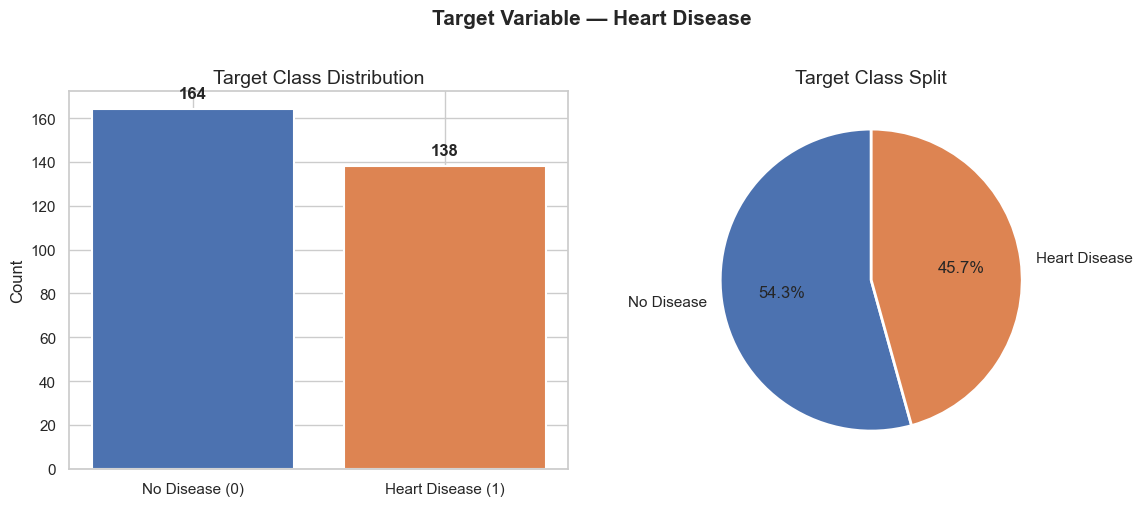

Class balance ratio: 0.84


In [7]:
import os
os.makedirs('../plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart: Count of each target class (0 = no disease, 1 = heart disease)
target_counts = df['target'].value_counts()

axes[0].bar(
    ['No Disease (0)', 'Heart Disease (1)'],
    target_counts.values,
    color=['#4C72B0', '#DD8452'],  # blue = no disease, orange = disease
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

# Annotate each bar with its exact count
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# --- Pie Chart: Proportional split between classes ---
axes[1].pie(
    target_counts.values,
    labels=['No Disease', 'Heart Disease'],
    autopct='%1.1f%%',          # show percentage to 1 decimal place
    colors=['#4C72B0', '#DD8452'],
    startangle=90,               # start from top of circle
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Target Class Split')

plt.suptitle('Target Variable — Heart Disease', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Class balance ratio: values close to 1.0 indicate a balanced dataset
print(f'Class balance ratio: {target_counts[0]/target_counts[1]:.2f}')

## 5. Univariate Analysis — Continuous Features

Examining individual distributions to check for skewness and outliers.

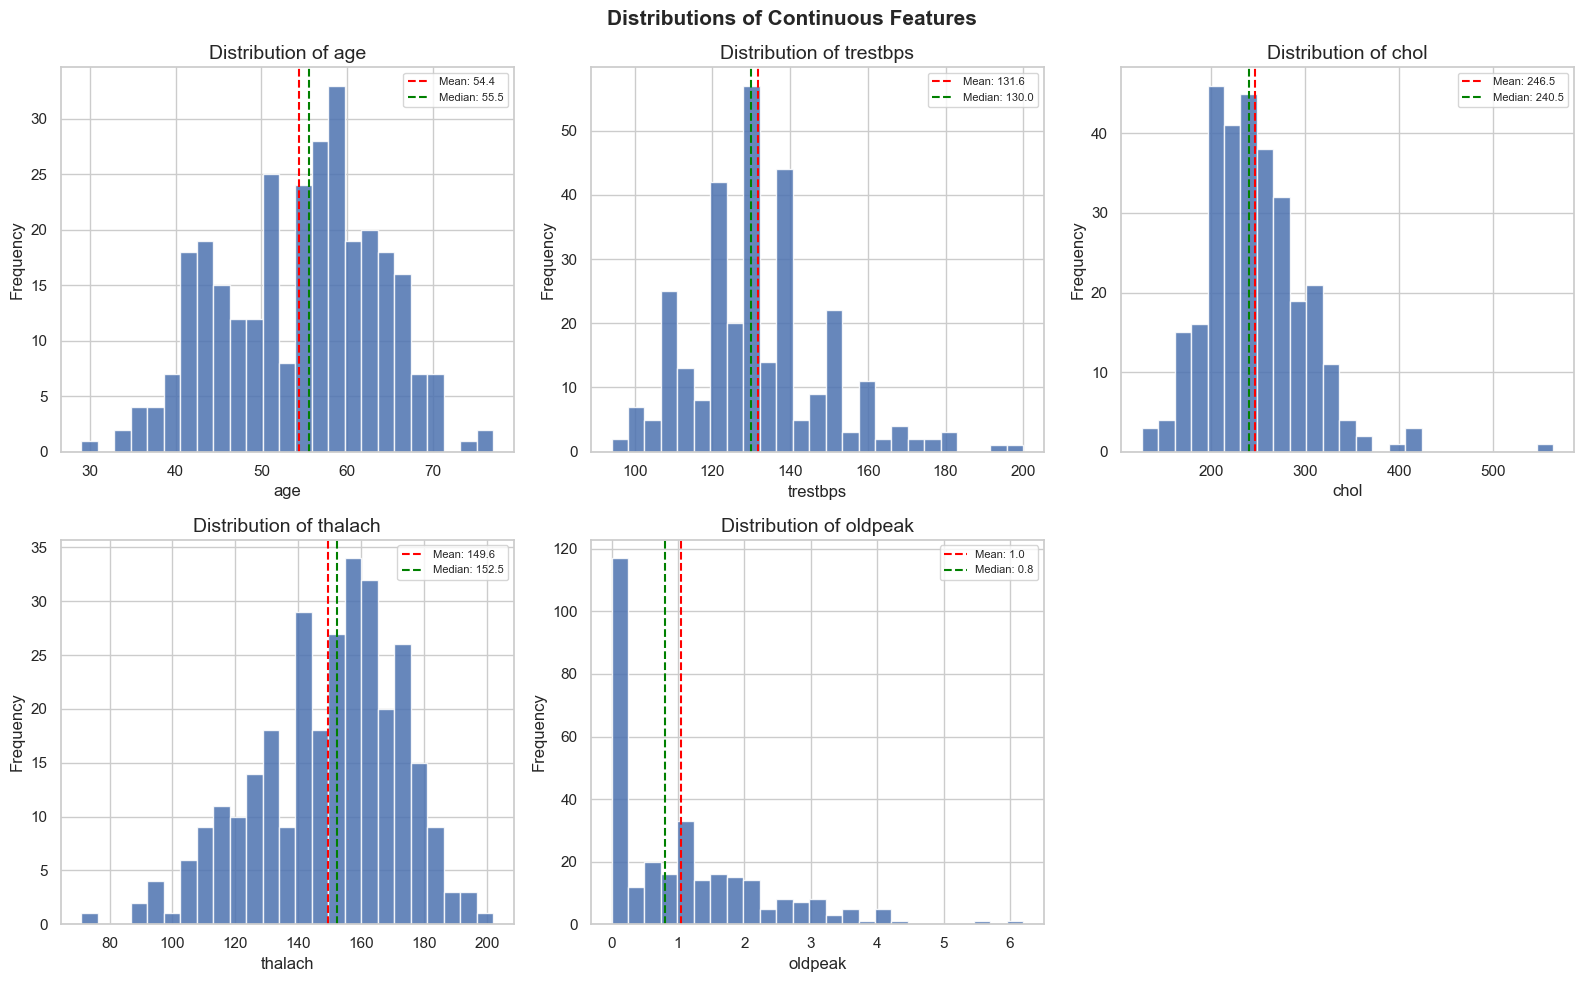

In [8]:
# Continuous features to analyse
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Create a 2x3 grid of subplots (5 features + 1 empty)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # flatten to 1D so we can loop through easily

for i, col in enumerate(continuous_features):
    # Plot histogram for each feature
    axes[i].hist(df[col], bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

    # Overlay mean and median lines to spot skewness
    # If mean > median, distribution is right-skewed (and vice versa)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=8)

# Hide the 6th subplot since we only have 5 features
axes[-1].set_visible(False)

plt.suptitle('Distributions of Continuous Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Univariate Analysis — Categorical Features

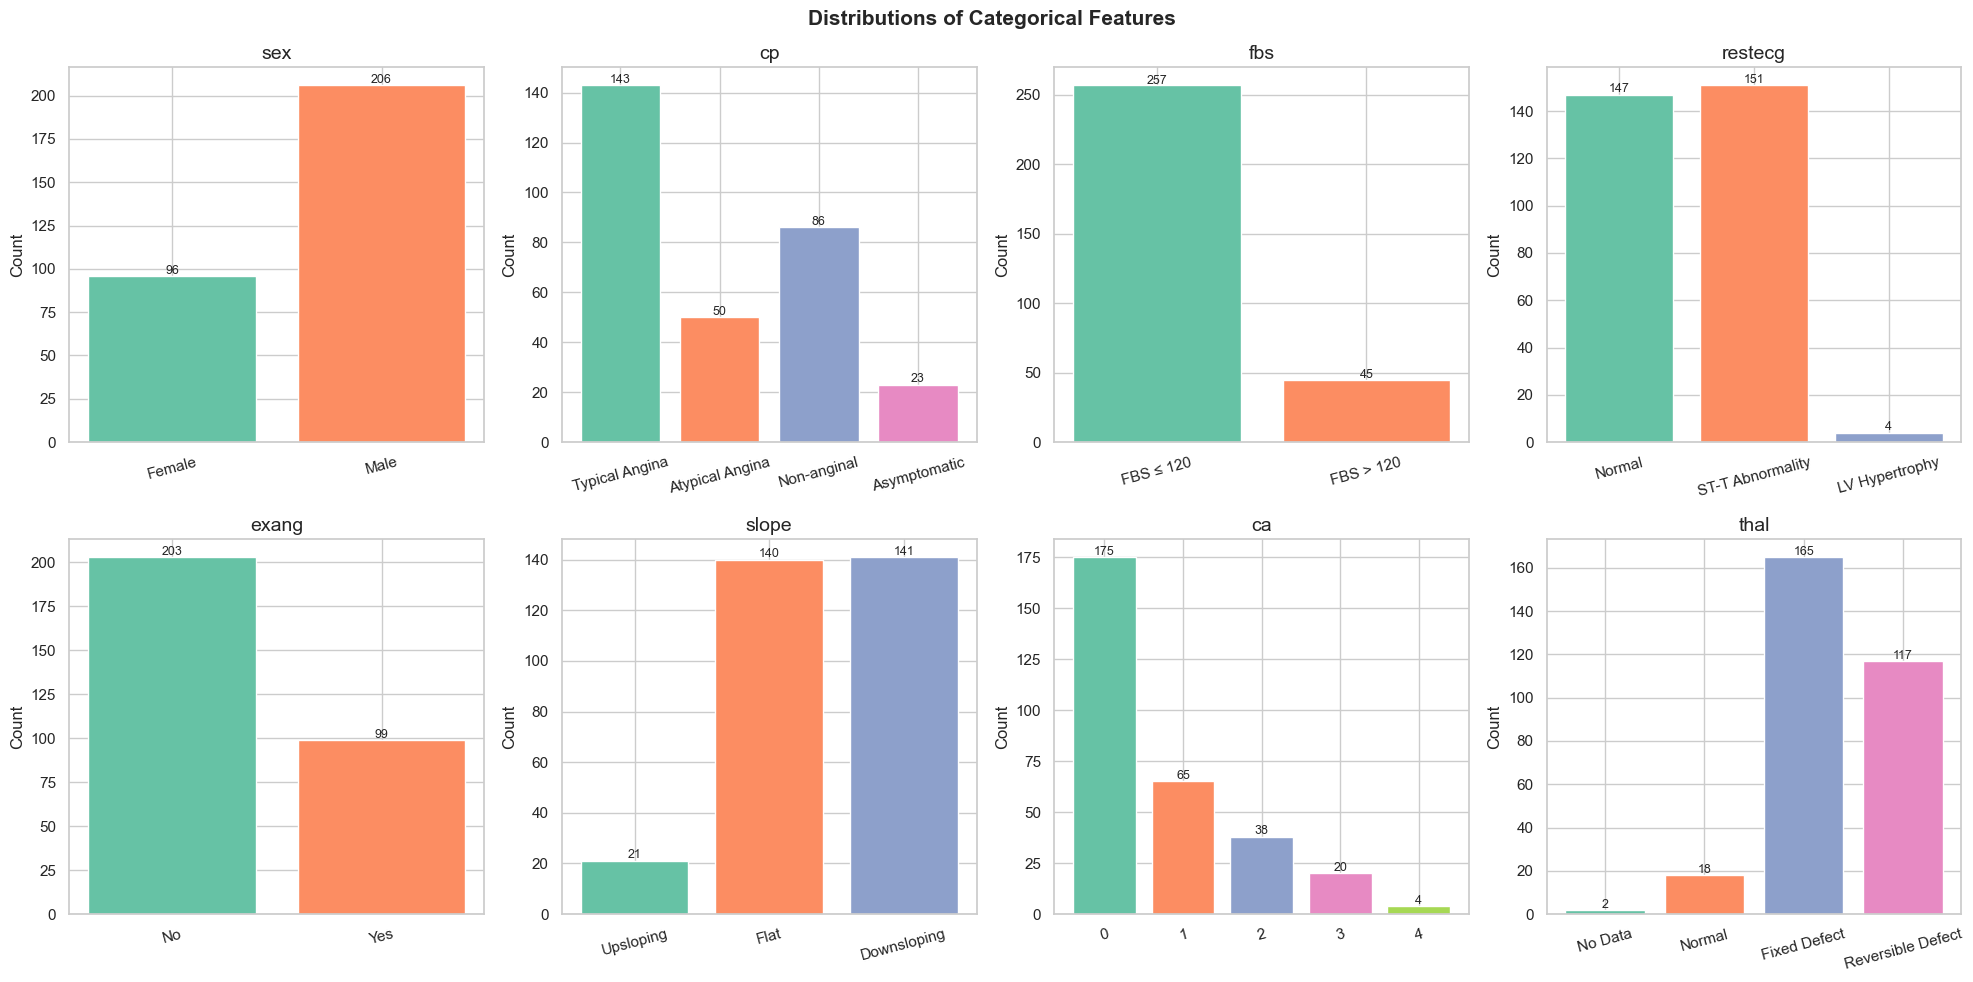

In [9]:
# Categorical features to analyse
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Human-readable labels for encoded categorical values
cat_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-anginal', 3: 'Asymptomatic'},
    'fbs': {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormality', 2: 'LV Hypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'thal': {0: 'No Data', 1: 'Normal', 2: 'Fixed Defect', 3: 'Reversible Defect'},
}

# 2x4 grid to fit all 8 categorical features
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    counts = df[col].value_counts().sort_index()  # sort by category value for consistency

    # Use readable labels where available, otherwise fall back to raw numeric value
    labels = [cat_labels[col].get(k, str(k)) if col in cat_labels else str(k) for k in counts.index]

    # Each category gets a distinct colour from the Set2 palette
    axes[i].bar(labels, counts.values, color=sns.color_palette('Set2', len(counts)), edgecolor='white')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)  # rotate labels to avoid overlap

    # Annotate each bar with its count
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Distributions of Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Bivariate Analysis — Features vs Target

How does each feature relate to the presence of heart disease?

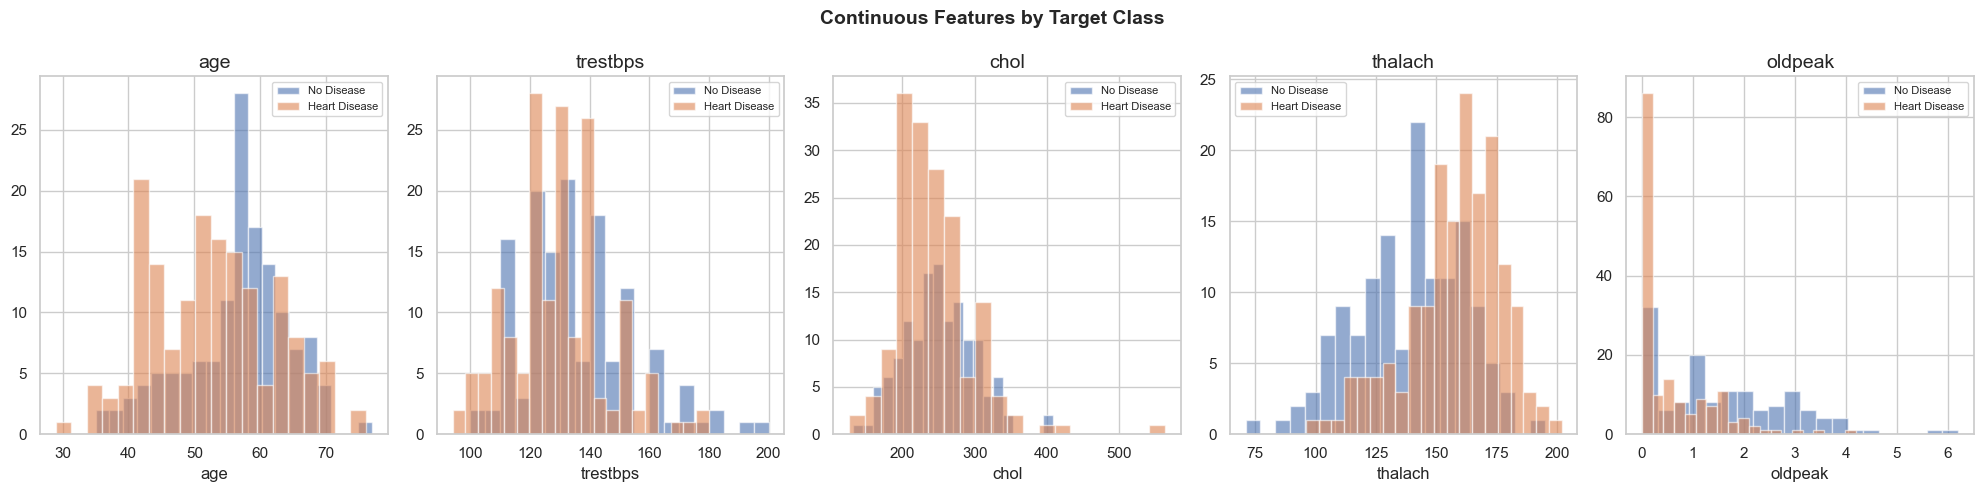

In [10]:
# Continuous features split by target
fig, axes = plt.subplots(1, len(continuous_features), figsize=(20, 5))

for i, col in enumerate(continuous_features):
    for target_val, label, color in zip([0, 1], ['No Disease', 'Heart Disease'], ['#4C72B0', '#DD8452']):
        axes[i].hist(df[df['target'] == target_val][col], bins=20,
                     alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Continuous Features by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/continuous_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

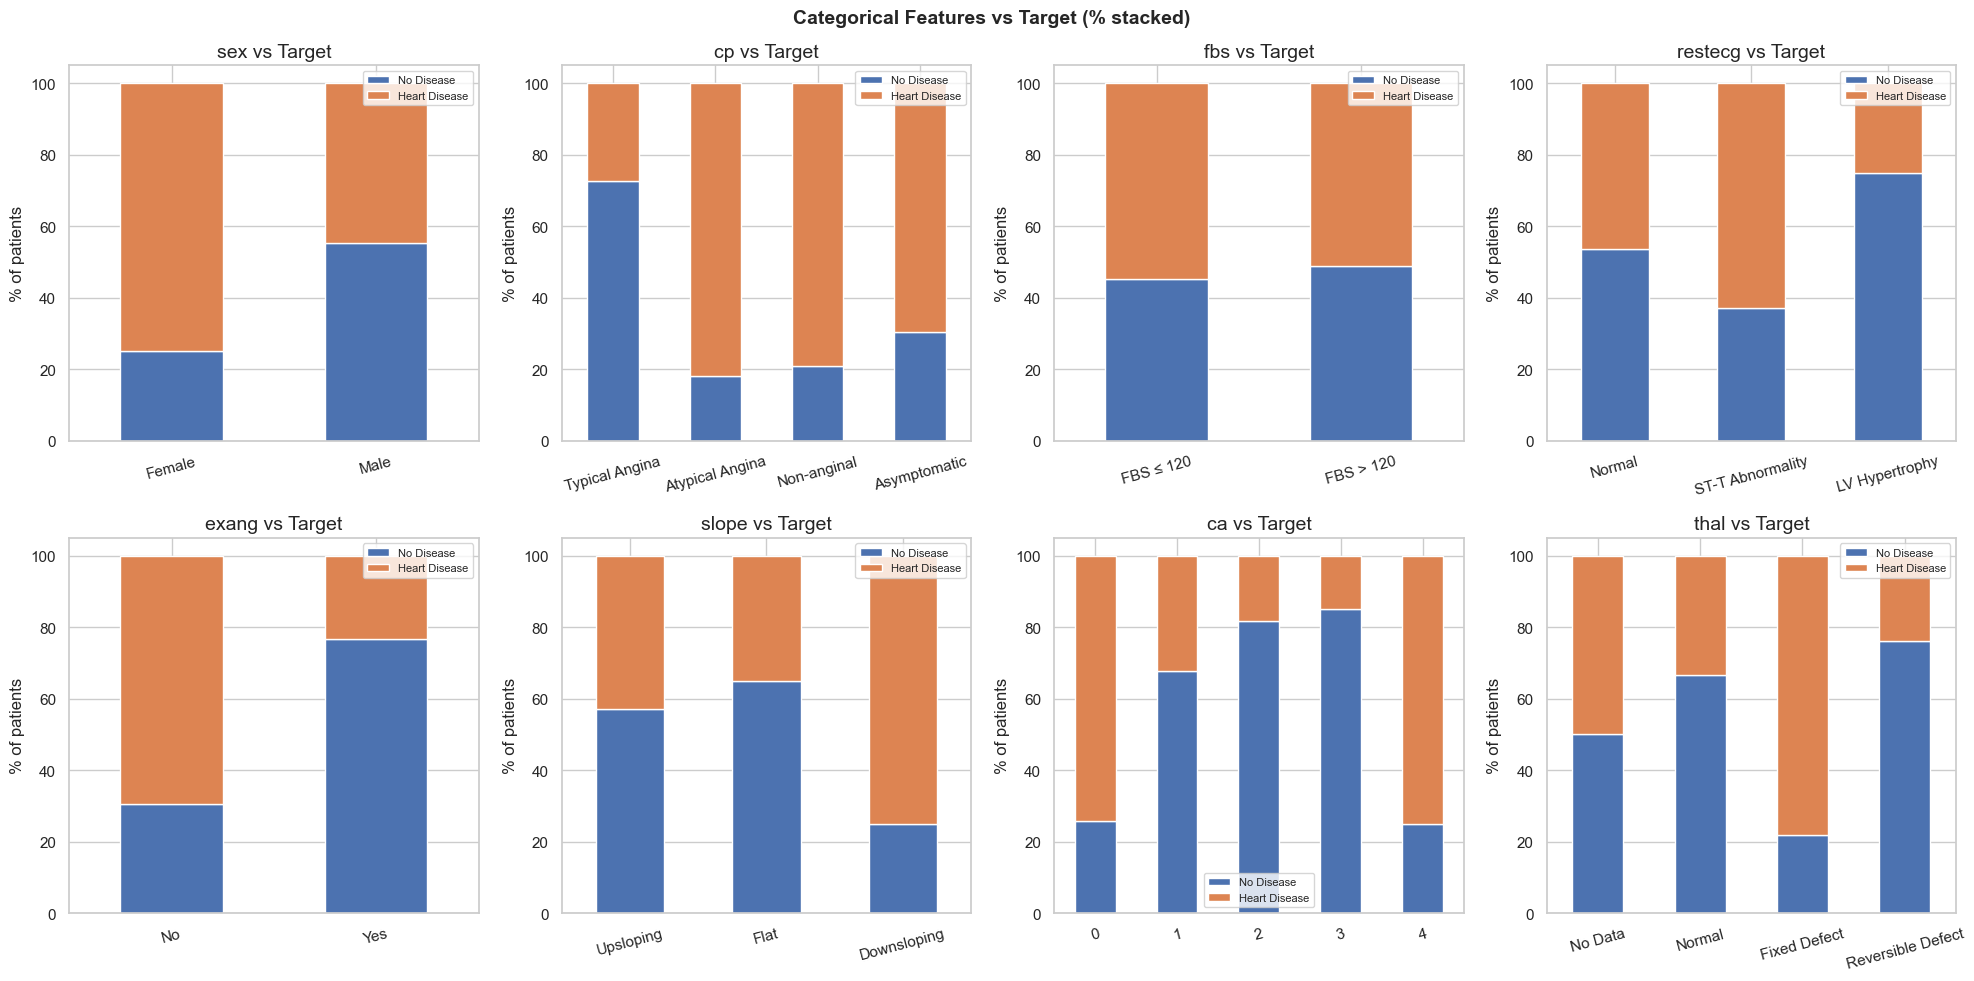

In [11]:
# Categorical features split by target — stacked percentage bar
# Shows what proportion of each category has/doesn't have heart disease
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # crosstab gives counts; normalize='index' converts each row to % (so bars always sum to 100%)
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.columns = ['No Disease', 'Heart Disease']

    # Apply readable labels to the index if available in cat_labels
    if col in cat_labels:
        ct.index = [cat_labels[col].get(k, str(k)) for k in ct.index]

    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_ylabel('% of patients')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)  # rotate to avoid label overlap
    axes[i].legend(fontsize=8)

plt.suptitle('Categorical Features vs Target (% stacked)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Outlier Detection — Boxplots

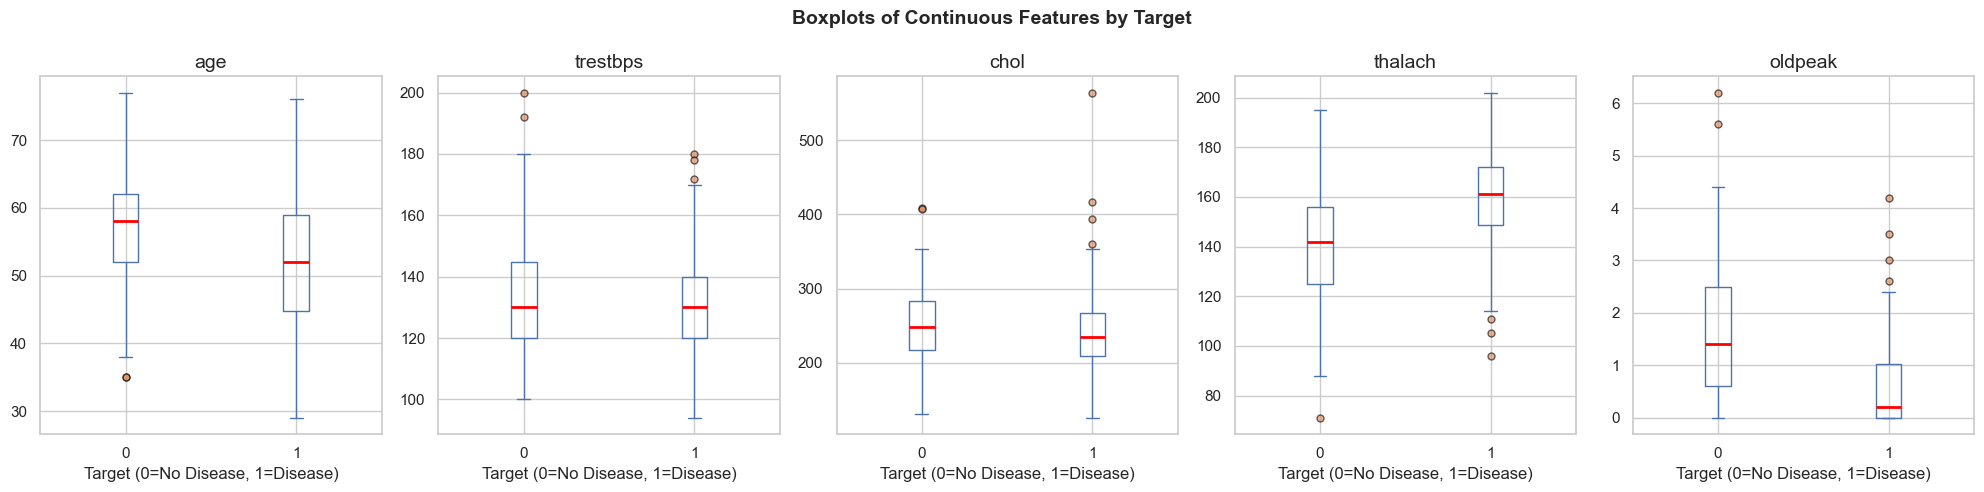

In [12]:
# Boxplots show the spread of each continuous feature split by target class
# Helps identify whether a feature separates the two classes — useful for feature selection
fig, axes = plt.subplots(1, len(continuous_features), figsize=(20, 5))

for i, col in enumerate(continuous_features):
    df.boxplot(
        column=col,
        by='target',       # split each boxplot by target class (0 vs 1)
        ax=axes[i],
        boxprops=dict(color='#4C72B0'),              # box outline
        medianprops=dict(color='red', linewidth=2),  # median line in red for visibility
        whiskerprops=dict(color='#4C72B0'),          # whiskers (min/max range)
        capprops=dict(color='#4C72B0'),              # caps at end of whiskers
        flierprops=dict(marker='o', markerfacecolor='#DD8452', markersize=5, alpha=0.6)  # outlier points
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')

plt.suptitle('Boxplots of Continuous Features by Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Correlation Analysis

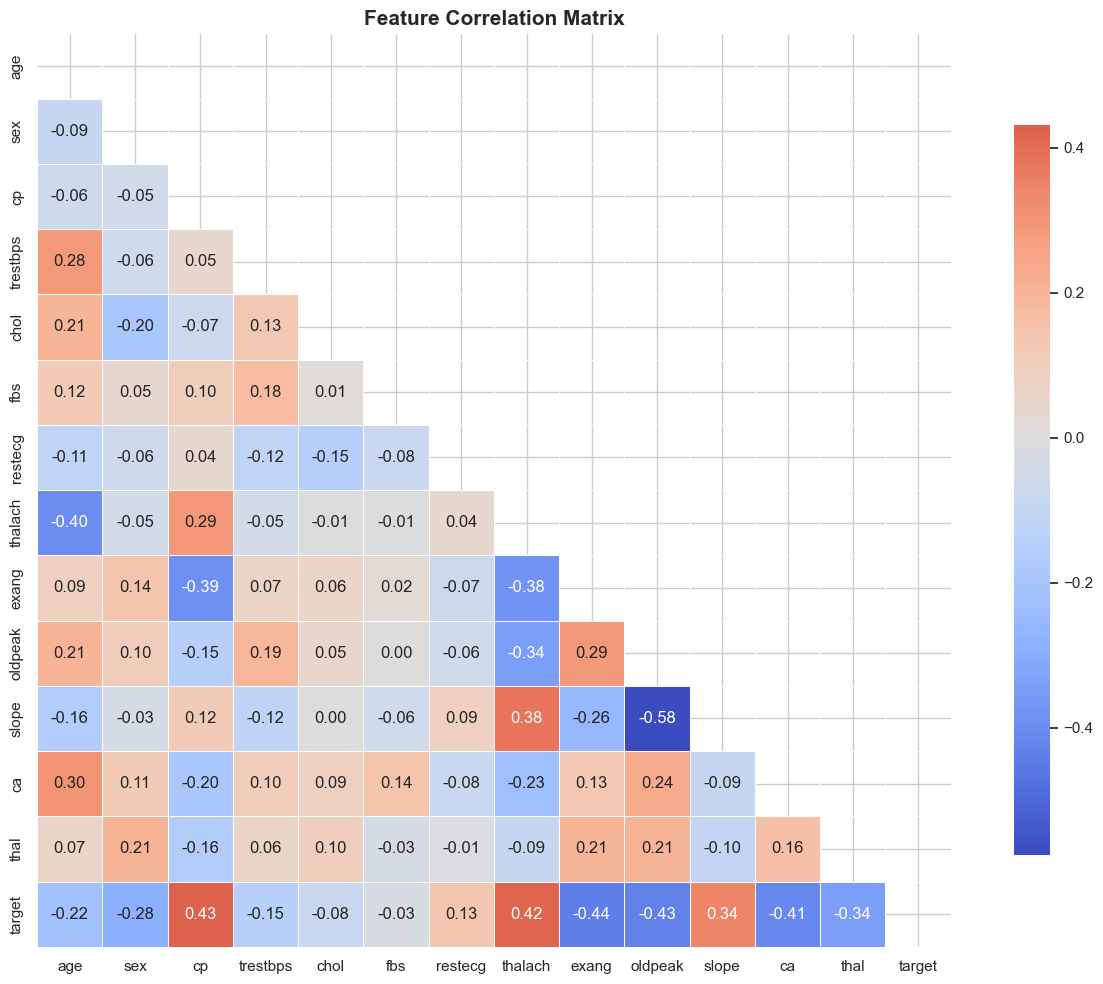

In [13]:
# Compute Pearson correlation coefficients between all features
# Values range from -1 (perfect negative) to +1 (perfect positive), 0 = no linear relationship
corr = df.corr()

plt.figure(figsize=(13, 10))

# Mask the upper triangle to avoid showing duplicate values (heatmap is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,          # show correlation values inside each cell
    fmt='.2f',           # round to 2 decimal places
    cmap='coolwarm',     # blue = negative correlation, red = positive
    center=0,            # centre the colour scale at 0 (no correlation)
    square=True,         # keep cells square for readability
    linewidths=0.5,      # thin grid lines between cells
    cbar_kws={'shrink': 0.8}  # slightly shrink the colour bar
)

plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

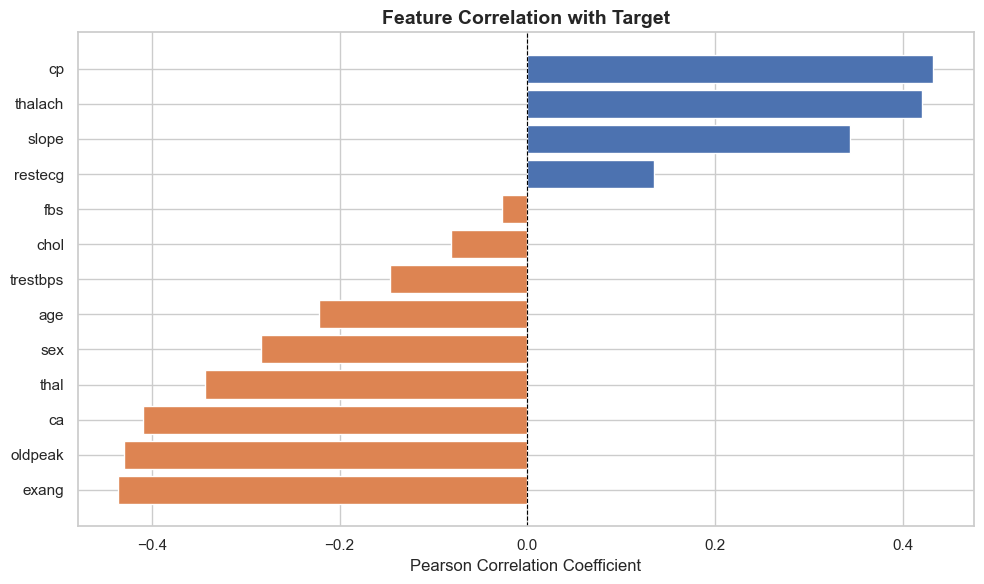


Top positive correlations with target:
cp         0.432080
thalach    0.419955
slope      0.343940
restecg    0.134874
Name: target, dtype: float64

Top negative correlations with target:
exang      -0.435601
oldpeak    -0.429146
ca         -0.408992
thal       -0.343101
sex        -0.283609
age        -0.221476
trestbps   -0.146269
chol       -0.081437
fbs        -0.026826
Name: target, dtype: float64


In [14]:
# Extract correlation of every feature with the target column only
# Sort ascending so strongest negative correlations appear at the top of the chart
target_corr = df.corr()['target'].drop('target').sort_values()

# Colour bars by direction: orange = positively correlated, blue = negatively correlated
colors = ['#DD8452' if x < 0 else '#4C72B0' for x in target_corr.values]

plt.figure(figsize=(10, 6))
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')

# Reference line at 0 — features to the right increase heart disease likelihood
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Target', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../plots/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked lists for easy reference in the write-up
print('\nTop positive correlations with target:')
print(target_corr[target_corr > 0].sort_values(ascending=False))
print('\nTop negative correlations with target:')
print(target_corr[target_corr < 0].sort_values())

## 10. Pairplot — Key Features

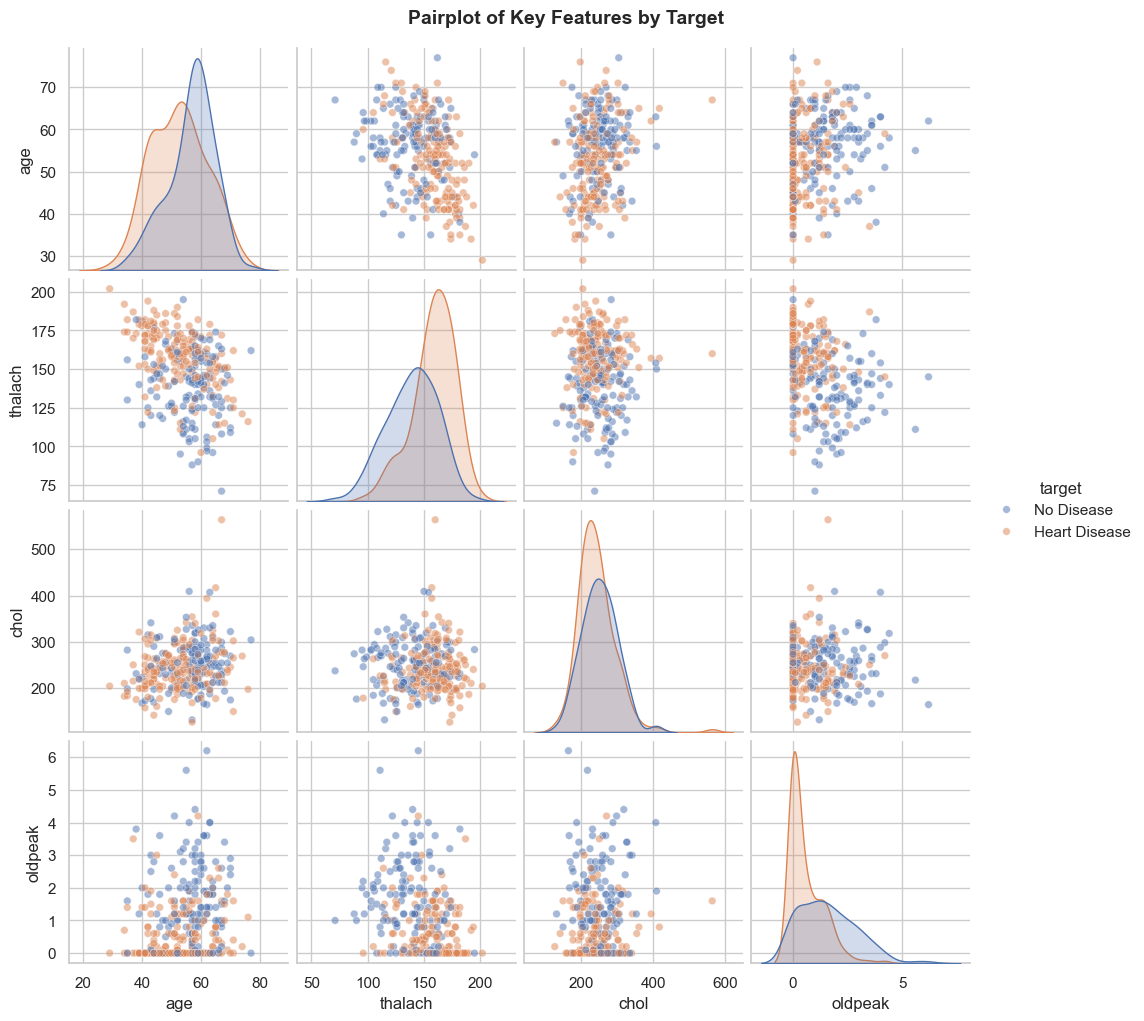

In [15]:
# Pairplot shows every combination of key features plotted against each other
# Helps spot which feature pairs best separate the two classes visually
key_features = ['age', 'thalach', 'chol', 'oldpeak', 'target']

# Copy to avoid modifying the original dataframe
pair_df = df[key_features].copy()

# Map numeric target to labels so the legend is readable
pair_df['target'] = pair_df['target'].map({0: 'No Disease', 1: 'Heart Disease'})

g = sns.pairplot(
    pair_df,
    hue='target',                                                        # colour points by class
    palette={'No Disease': '#4C72B0', 'Heart Disease': '#DD8452'},
    diag_kind='kde',       # diagonal shows density curve instead of histogram
    plot_kws={'alpha': 0.5, 's': 30}  # semi-transparent points to reduce overplotting
)

# y=1.02 prevents the title from overlapping the top row of plots
g.fig.suptitle('Pairplot of Key Features by Target', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../plots/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. EDA Summary & Key Findings

---

**Class Balance:**
- 164 patients have no heart disease (54.3%) and 138 have heart disease (45.7%)
- The dataset is nearly balanced (ratio: 1.19), so SMOTE (Synthetic Minority Oversampling Technique) or class weighting is not required

**Missing / Duplicate Data:**
- No missing values found across all 14 features
- 723 duplicate rows were detected and removed, reducing the dataset from 1,025 to 302 rows
- The smaller dataset increases the risk of overfitting — k-fold cross-validation (k=10) will be used during modelling

**Key Features (positively correlated with heart disease):**
- `cp` (r = +0.43) — strongest positive predictor; patients with typical angina had the lowest 
heart disease rate (~28%), while asymptomatic patients had the highest (~70%)
- `thalach` (r = +0.42) — heart disease patients had noticeably higher max heart rates; 
distributions are visually separated in both the histogram and pairplot
- `slope` (r = +0.34) — downsloping ST segments were almost entirely associated with heart disease
- `restecg` (r = +0.13) — patients with LV hypertrophy showed higher disease rates (~75%)

**Key Features (negatively correlated with heart disease):**
- `exang` (r = −0.44) — strongest negative predictor; 70%+ of patients with exercise-induced 
angina had no heart disease
- `oldpeak` (r = −0.43) — no-disease patients had higher ST depression values; heavy right skew 
with outliers up to 6.0 noted
- `ca` (r = −0.41) — patients with 0 coloured vessels had the highest disease rate (~75%); 
risk drops as vessel count increases
- `thal` (r = −0.34) — patients with a reversible defect were predominantly disease-free
- `age` (r = −0.22) — no-disease patients were slightly older (median ~58) vs disease (median ~52)
- `sex` (r = −0.28) — females had a much higher disease rate (~75%) despite fewer total cases

**Weak / Negligible Features:**
- `fbs` (r = −0.08) — fasting blood sugar shows almost no relationship with target; 
near 50/50 split in both categories
- `chol` (r = −0.08) and `trestbps` (r = −0.15) — distributions heavily overlap between 
classes, suggesting limited predictive power alone

**Outliers:**
- `chol`: one extreme outlier above 500 mg/dl visible in boxplot and pairplot — to be 
investigated in preprocessing
- `trestbps`: outlier near 200 mm Hg in the no-disease group
- `oldpeak`: several outliers above 4.0; heavy right skew — may require log transformation
- `thalach`: one outlier near 75 bpm in the no-disease group

**Next Step:** Move to `2_preprocessing.ipynb` to handle outliers, encode categoricals, 
and scale features.